# Ejercicio 3 — Titanic

---

> **Importe y explore el conjunto de datos `titanic.csv`.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

---
## Ítem 1

> **Realice una descripción general del conjunto de datos que incluya la descripción de la información brindada por cada columna, el tipo de datos que contiene cada una y el número de registros.**

In [2]:
df = pd.read_csv('../Datasets/titanic.csv')
print(f'Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}')
df.head(3)

Filas: 1309  |  Columnas: 21


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked,WikiId,Name_wiki,Age_wiki,Hometown,Boarded,Destination,Lifeboat,Body,Class
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,S,691.0,"Braund, Mr. Owen Harris",22.0,"Bridgerule, Devon, England",Southampton,"Qu'Appelle Valley, Saskatchewan, Canada",NaN,NaN,3.0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,C,90.0,"Cumings, Mrs. Florence Briggs (née Thayer)",35.0,"New York, New York, US",Cherbourg,"New York, New York, US",4,NaN,1.0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,S,865.0,"Heikkinen, Miss Laina",26.0,"Jyväskylä, Finland",Southampton,New York City,14?,NaN,3.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   str    
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    str    
 11  Embarked     1307 non-null   str    
 12  WikiId       1304 non-null   float64
 13  Name_wiki    1304 non-null   str    
 14  Age_wiki     1302 non-null   float64
 15  Hometown     1304 non-null   str    
 16  Boarded      1304 non-null   str    
 17  Destination  1304 non-null   str    
 18  Lifeboat     502 non-null    str    
 19  Body         130 

### Descripción de columnas

| Columna | Tipo | Descripción |
|---|---|---|
| `PassengerId` | int | Identificador del pasajero |
| `Survived` | float (0/1) | 0 = murió, 1 = sobrevivió |
| `Pclass` | int | Clase del pasaje (1, 2, 3) |
| `Name` | str | Nombre completo |
| `Sex` | str | Sexo |
| `Age` | float | Edad en años |
| `SibSp` | int | N° de hermanos/cónyuge a bordo |
| `Parch` | int | N° de padres/hijos a bordo |
| `Ticket` | str | Número de boleto |
| `Fare` | float | Precio del pasaje |
| `Cabin` | str | Número de cabina |
| `Embarked` | str | Puerto de embarque (S/C/Q) |
| `Boarded` | str | Ciudad de embarque |
| `Destination` | str | Destino |
| `Lifeboat` | str | Bote salvavidas |
| `Body` | str | N° de cuerpo recuperado |

---
## Ítem 2

> **Realice cualquier tipo de limpieza y adecuación del dataset que considere necesaria para su posterior análisis, incluyendo manejo de valores faltantes y de datos duplicados y/o potencialmente erróneos.**

In [4]:
print('Valores faltantes por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')

Valores faltantes por columna:
PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
WikiId            5
Name_wiki         5
Age_wiki          7
Hometown          5
Boarded           5
Destination       5
Lifeboat        807
Body           1179
Class             5
dtype: int64

Registros duplicados: 0


In [5]:
df = df.drop_duplicates()

# Convertir Survived a int nullable
df['Survived'] = df['Survived'].astype('Int64')

# Age: imputar con mediana por clase (conserva registros)
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# Embarked: imputar con moda
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print(f'Shape final: {df.shape}')
print('Valores faltantes en columnas de análisis:')
print(df[['Survived', 'Pclass', 'Age', 'Fare', 'Embarked']].isnull().sum())

Shape final: (1309, 21)
Valores faltantes en columnas de análisis:
Survived    418
Pclass        0
Age           0
Fare          1
Embarked      0
dtype: int64


---
## Ítem 3

> **Calcule la media, la mediana y la desviación estándar de la edad de los/las pasajeros/as que murieron y sobrevivieron para cada clase. Realice un boxplot que muestre la distribución de edades para cada grupo (murieron/sobrevivieron) dentro de cada clase.**
> - ¿En qué clase las edades de las personas que sobrevivieron fueron más variables?
> - ¿Cuál fue la edad de la persona más joven que sobrevivió en tercera clase?

In [6]:
df['survived_label'] = df['Survived'].map({1: 'Sobrevivió', 0: 'Murió'})

stats_edad = df.groupby(['Pclass', 'survived_label'])['Age'].agg(['mean', 'median', 'std']).round(2)
stats_edad.columns = ['Media', 'Mediana', 'Desvío estándar']
stats_edad.index.names = ['Clase', 'Estado']
print(stats_edad)

                  Media  Mediana  Desvío estándar
Clase Estado                                     
1     Murió       42.76     39.0            13.78
      Sobrevivió  35.74     36.0            13.07
2     Murió       33.22     30.0            11.76
      Sobrevivió  26.04     28.0            14.50
3     Murió       25.85     24.0            10.57
      Sobrevivió  21.60     24.0            10.23


C:\Users\PC\AppData\Local\Temp\ipykernel_16884\3632569276.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\PC\AppData\Local\Temp\ipykernel_16884\3632569276.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\PC\AppData\Local\Temp\ipykernel_16884\3632569276.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


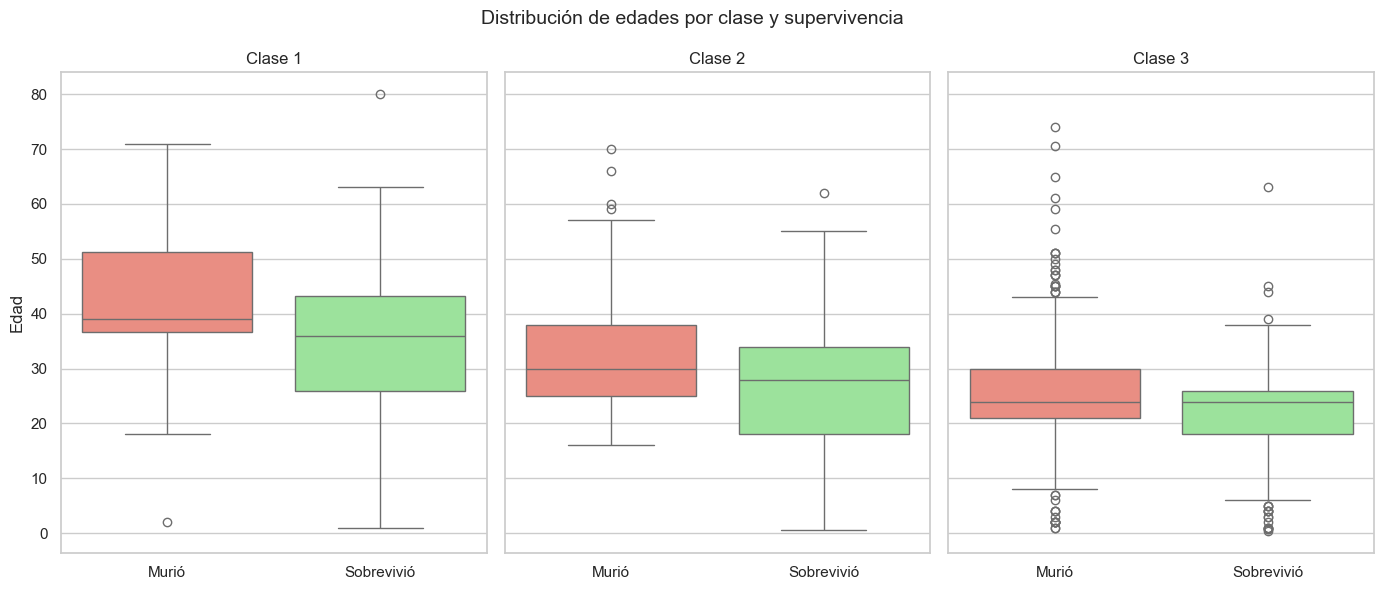

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=True)
for i, clase in enumerate([1, 2, 3]):
    subset = df[df['Pclass'] == clase]
    sns.boxplot(
        data=subset,
        x='survived_label',
        y='Age',
        palette=['salmon', 'lightgreen'],
        order=['Murió', 'Sobrevivió'],
        ax=axes[i]
    )
    axes[i].set_title(f'Clase {clase}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Edad' if i == 0 else '')

fig.suptitle('Distribución de edades por clase y supervivencia', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
std_sobrevivientes = df[df['Survived'] == 1].groupby('Pclass')['Age'].std()
print('Desvío estándar de edad entre sobrevivientes por clase:')
print(std_sobrevivientes.round(2))
print(f'Mayor variabilidad: Clase {std_sobrevivientes.idxmax()}')

min_edad_clase3 = df[(df['Survived'] == 1) & (df['Pclass'] == 3)]['Age'].min()
print(f'\nEdad de la persona más joven que sobrevivió en 3ra clase: {min_edad_clase3}')

Desvío estándar de edad entre sobrevivientes por clase:
Pclass
1    13.07
2    14.50
3    10.23
Name: Age, dtype: float64
Mayor variabilidad: Clase 2

Edad de la persona más joven que sobrevivió en 3ra clase: 0.42


---
## Ítem 4

> **Represente gráficamente la distribución de los precios de los pasajes en función de la clase del pasajero y calcule el promedio, la moda, la mediana, la desviación estándar y el rango intercuartil del precio del pasaje para cada grupo. ¿En qué clase los precios de pasaje presentaron una mayor variabilidad?**

C:\Users\PC\AppData\Local\Temp\ipykernel_16884\2315397035.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


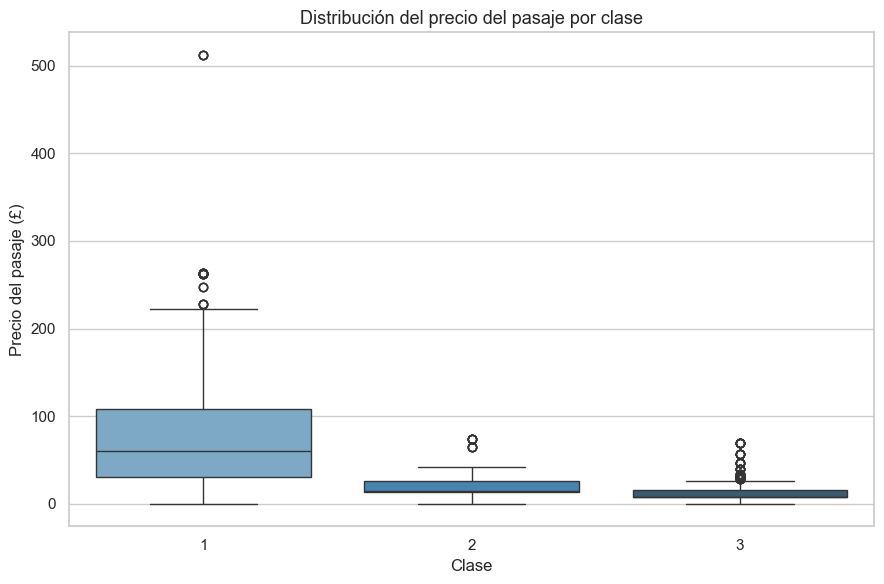

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(
    data=df,
    x='Pclass',
    y='Fare',
    palette='Blues_d',
    ax=ax
)
ax.set_title('Distribución del precio del pasaje por clase', fontsize=13)
ax.set_xlabel('Clase')
ax.set_ylabel('Precio del pasaje (£)')
plt.tight_layout()
plt.show()

In [10]:
def moda(x):
    return x.mode().iloc[0] if not x.mode().empty else np.nan

stats_fare = df.groupby('Pclass')['Fare'].agg(
    Promedio='mean',
    Mediana='median',
    Moda=moda,
    Desvio_std='std'
).round(2)

ric_fare = df.groupby('Pclass')['Fare'].apply(
    lambda x: round(x.quantile(0.75) - x.quantile(0.25), 2)
).rename('RIC')
stats_fare = stats_fare.join(ric_fare)

print(stats_fare)
print(f"\nClase con mayor variabilidad (mayor desvío estándar): Clase {stats_fare['Desvio_std'].idxmax()}")

        Promedio  Mediana   Moda  Desvio_std    RIC
Pclass                                             
1          87.51    60.00  26.55       80.45  76.97
2          21.18    15.05  13.00       13.61  13.00
3          13.30     8.05   8.05       11.49   7.50

Clase con mayor variabilidad (mayor desvío estándar): Clase 1


---
## Ítem 5

> - **¿Qué medida resumen calcularía si quisiera conocer aquel valor que representa el precio que sólo el 25% de los pasajeros superaron a la hora de comprar su boleto?**
> - **Identifique cuáles fueron los pasajeros que pagaron un pasaje igual o más caro que el valor calculado en el ítem anterior. Construya una tabla en la que se informen los nombres de estas personas, el número total de personas vinculadas a ellas que se encontraban en el barco y la ciudad en la que embarcaron.**
> - **En base a la tabla construida en el ítem anterior, ¿con cuántos acompañantes, en promedio, viajaban estos pasajeros? ¿En qué puerto embarcó la mayoría de ellos?**

In [11]:
# El valor superado por el 25% más caro = percentil 75 (Q3)
p75_fare = df['Fare'].quantile(0.75)
print(f'Medida: Percentil 75 (Q3)')
print(f'Valor: £{p75_fare:.2f}')
print('(El 25% de los pasajeros pagó más que este valor.)')

Medida: Percentil 75 (Q3)
Valor: £31.27
(El 25% de los pasajeros pagó más que este valor.)


In [12]:
pasajeros_caros = df[df['Fare'] >= p75_fare].copy()
pasajeros_caros['total_en_barco'] = pasajeros_caros['SibSp'] + pasajeros_caros['Parch'] + 1

tabla_caros = pasajeros_caros[['Name', 'total_en_barco', 'Boarded']].reset_index(drop=True)
print(f'Pasajeros con pasaje >= £{p75_fare:.2f}: {len(tabla_caros)}')
tabla_caros.head(10)

Pasajeros con pasaje >= £31.27: 330


,Name,total_en_barco,Boarded
0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2,Cherbourg
1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",2,Southampton
2,"McCarthy, Mr. Timothy J",1,Southampton
3,"Andersson, Mr. Anders Johan",7,Southampton
4,"Sloper, Mr. William Thompson",1,Southampton
5,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",7,Southampton
6,"Fortune, Mr. Charles Alexander",6,Southampton
7,"Spencer, Mrs. William Augustus (Marie Eugenie)",2,Cherbourg
8,"Meyer, Mr. Edgar Joseph",2,Cherbourg
9,"Holverson, Mr. Alexander Oskar",2,Southampton


In [13]:
acomp_prom = (pasajeros_caros['SibSp'] + pasajeros_caros['Parch']).mean()
print(f'Promedio de acompañantes (SibSp + Parch): {acomp_prom:.2f}')

puerto_mayorit = pasajeros_caros['Boarded'].value_counts()
print(f'\nDistribución por ciudad de embarque:')
print(puerto_mayorit)
print(f'\nCiudad de embarque de la mayoría: {puerto_mayorit.idxmax()}')

Promedio de acompañantes (SibSp + Parch): 1.89

Distribución por ciudad de embarque:
Boarded
Southampton    210
Cherbourg      117
Belfast          1
Name: count, dtype: int64

Ciudad de embarque de la mayoría: Southampton


---
## Ítem 6

> **Construya una tabla en la que se resuma la distribución de pasajeros del Titanic en función de la clase en la que viajaron. La misma debe contener la siguiente información (en distintas columnas): cantidad de pasajeros/as que viajaron en cada clase y porcentajes en relación al total. ¿A qué clase pertenecía la mayoría de los pasajeros del Titanic?**

In [14]:
dist_clase = df['Pclass'].value_counts().sort_index()
dist_rel = (dist_clase / len(df) * 100).round(2)
tabla_clase = pd.DataFrame({
    'Cantidad de pasajeros': dist_clase,
    'Porcentaje (%)': dist_rel
})
tabla_clase.index.name = 'Clase'
print(tabla_clase)
print(f"\nClase con más pasajeros: {dist_clase.idxmax()} ({dist_clase.max()} pasajeros)")

       Cantidad de pasajeros  Porcentaje (%)
Clase                                       
1                        323           24.68
2                        277           21.16
3                        709           54.16

Clase con más pasajeros: 3 (709 pasajeros)


---
## Ítem 7

> **Construya una tabla de contingencia cruzando las variables `survived` y `Pclass`. ¿Qué proporción de personas de cada clase sobrevivieron al naufragio del Titanic? Represente gráficamente esta información en un gráfico de barras.**

In [15]:
contingencia = pd.crosstab(
    df['Pclass'],
    df['Survived'],
    margins=True,
    margins_name='Total'
)
contingencia.columns = ['Murió', 'Sobrevivió', 'Total']
contingencia.index.name = 'Clase'
print(contingencia)

print('\nProporción de sobrevivientes por clase:')
prop_surv = df.groupby('Pclass')['Survived'].mean().round(3) * 100
for clase, pct in prop_surv.items():
    print(f'  Clase {clase}: {pct:.1f}%')

       Murió  Sobrevivió  Total
Clase                          
1         80         136    216
2         97          87    184
3        372         119    491
Total    549         342    891

Proporción de sobrevivientes por clase:
  Clase 1: 63.0%
  Clase 2: 47.3%
  Clase 3: 24.2%


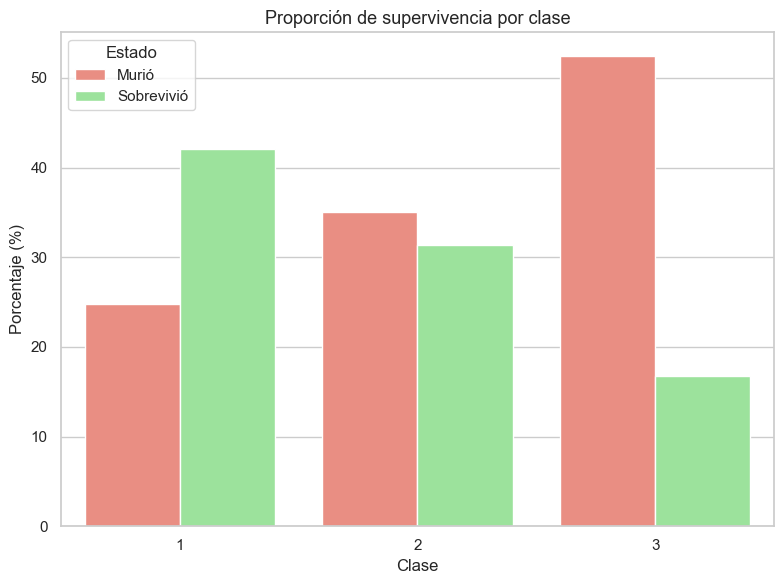

In [16]:
prop_df = df.groupby(['Pclass', 'survived_label']).size().reset_index(name='count')
total_por_clase = df.groupby('Pclass').size().reset_index(name='total')
prop_df = prop_df.merge(total_por_clase, on='Pclass')
prop_df['proporcion'] = prop_df['count'] / prop_df['total'] * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(
    data=prop_df,
    x='Pclass',
    y='proporcion',
    hue='survived_label',
    palette={'Murió': 'salmon', 'Sobrevivió': 'lightgreen'},
    ax=ax
)
ax.set_title('Proporción de supervivencia por clase', fontsize=13)
ax.set_xlabel('Clase')
ax.set_ylabel('Porcentaje (%)')
ax.legend(title='Estado')
plt.tight_layout()
plt.show()